In [10]:
from transformers import pipeline

model = pipeline("sentiment-analysis")
print(model("I love this project"))

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9666.86it/s]


[{'label': 'POSITIVE', 'score': 0.999884843826294}]


In [11]:
print(model("This is terrible"))
print(model("I'm not sure how I feel about this"))

[{'label': 'NEGATIVE', 'score': 0.9996459484100342}]
[{'label': 'NEGATIVE', 'score': 0.9991093277931213}]


In [12]:
import requests

API_KEY = "b2a0d07341544104b699c5576a1bf7fd"

url = "https://newsapi.org/v2/everything"
params = {
    "q": "finance AND (stock market OR investment)",
    "language": "en",
    "apiKey": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

articles = data["articles"]

news_list = []
for article in articles:
    text = article["title"] + " " + str(article["description"])
    news_list.append(text)

print(news_list[:3])

['SpaceX in your index fund, explained Index funds are touted as one of the safest ways to invest. Rather than picking and choosing individual stocks, index funds let you bet on the market as a whole. So what happens when a company like SpaceX - a giant gamble, and, in my opinion, terribly overpri…', "Humanoid Robot Maker Unitree Pops an Outrageous 629% in Trading Debut It's reminiscent of a stock from the height of the dot-com craze, but we're sure that's nothing to worry about.", "What Berkshire's huge wager on Alphabet says about Warren Buffett's post-CEO role Berkshire Hathaway has built a nearly $38 billion Alphabet stake from scratch in under a year. It seems likely Warren Buffett is spearheading the investment."]


In [13]:
# To get more articles

In [14]:
import requests
from datetime import datetime, timedelta

API_KEY = "b2a0d07341544104b699c5576a1bf7fd"
url = "https://newsapi.org/v2/everything"

# Query parameters
query = "finance AND (stock market OR investment)"
language = "en"
page_size = 100  # max per request

# Date range setup: last 30 days
end_date = datetime.today()
start_date = end_date - timedelta(days=30)

all_articles = []

# Split the 30-day range into 3-day chunks (adjust as needed)
delta = timedelta(days=3)
current_start = start_date

while current_start < end_date:
    current_end = min(current_start + delta, end_date)
    
    page = 1
    while True:
        params = {
            "q": query,
            "language": language,
            "pageSize": page_size,
            "page": page,
            "from": current_start.strftime("%Y-%m-%d"),
            "to": current_end.strftime("%Y-%m-%d"),
            "apiKey": API_KEY
        }

        response = requests.get(url, params=params)
        data = response.json()

        if "articles" in data and data["articles"]:
            all_articles.extend(data["articles"])
            if len(data["articles"]) < page_size:
                break  # No more pages for this date range
            page += 1
        else:
            break  # No articles for this page/date range

    current_start += delta

# Extract text
news_list = []
for article in all_articles:
    text = article.get("title", "") + " " + str(article.get("description", ""))
    news_list.append(text)

print(f"Total articles fetched: {len(news_list)}")
print(news_list[:10])

Total articles fetched: 997
["Morning Bid: Magnificent cash burn July 23 (Reuters) - What matters in U. and global markets today, Editor-at-Large, Finance and Markets There was a familiar playbook in response to Alphabet'...", "Mbanq secures inaugural institutional funding investment The programme, recently listed on the Düsseldorf Stock Exchange, supports the expansion of the company's lending and Earned Wage Access platform", 'Alphabet flops, Intel shocks, and Tesla tanks: AlphaSpace weekly recap Some markets observations, compliments of Yahoo Finance AlphaSpace.', 'Top 3 US Stock Market Stories From This Week Top US stock market stories this week: Tesla’s drop, $100 oil and volatile chip stocks as AI spending rattles Wall Street.', "Warren Buffett says 'humans love to gamble' as he takes digs at a speculative market — so why do investors ignore him? The Berkshire Hathaway chair compared the stock market earlier this year to “a church with a casino attached.”", "Cathie Wood buys $8.7

In [15]:
results = []

for news in news_list:
    result = model(news[:512])[0]
    results.append(result)

print(results[:7])

[{'label': 'POSITIVE', 'score': 0.9701626300811768}, {'label': 'POSITIVE', 'score': 0.9984153509140015}, {'label': 'NEGATIVE', 'score': 0.9399424195289612}, {'label': 'NEGATIVE', 'score': 0.9585098624229431}, {'label': 'NEGATIVE', 'score': 0.9871627688407898}, {'label': 'POSITIVE', 'score': 0.7848635911941528}, {'label': 'POSITIVE', 'score': 0.9833247661590576}]


In [16]:
import json
score_map = {"POSITIVE": "Bullish", "NEGATIVE": "Bearish"}
sentiment_counts = {"Bullish": 0, "Bearish": 0, "Neutral": 0}

for r in results:
    label = r["label"]
    score = r["score"]

    if score < 0.6:
        sentiment_counts["Neutral"] += 1
    else:
        sentiment_counts[score_map[label]] += 1

print("Calculated Sentiment Counts:", sentiment_counts)

Calculated Sentiment Counts: {'Bullish': 351, 'Bearish': 616, 'Neutral': 30}


In [17]:
with open("results.json", "w") as f:
    json.dump(sentiment_counts, f, indent=4)

print("Saved results to results.json successfully!")

Saved results to results.json successfully!


In [18]:
import pandas as pd

df = pd.DataFrame(results)
print(df.head())

      label     score
0  POSITIVE  0.970163
1  POSITIVE  0.998415
2  NEGATIVE  0.939942
3  NEGATIVE  0.958510
4  NEGATIVE  0.987163


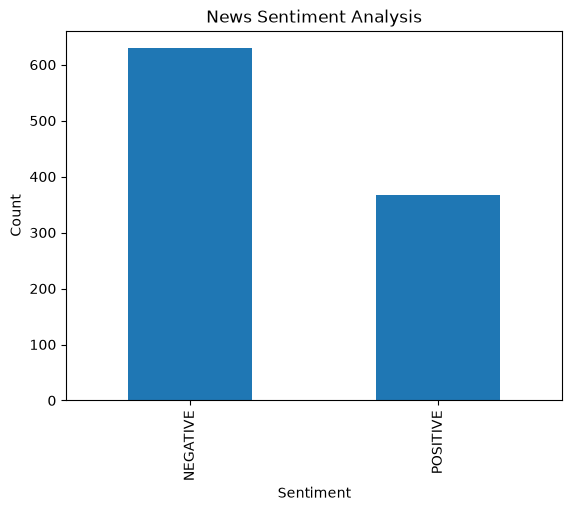

In [19]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("News Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()